In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = 'Summary GJ.XLSX'  # Ensure the file exists in the working directory
sheet_name = 'Summary - Jan to Jun'

try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    exit()
except Exception as e:
    print(f"Error loading file: {e}")
    exit()

# Data cleaning steps
# 1. Handle missing values
df.fillna(0, inplace=True)

# 2. Convert date columns to datetime safely
date_cols = ['ORDER DATE', 'SHIP DATE', 'PCD', 'Customer Ship Date']
date_cols = [col for col in date_cols if col in df.columns]  # Ensure columns exist
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. Clean numeric columns safely
numeric_cols = ['QNTY', 'FOB', 'SHIPPED QNTY', 'SHORT/EXCESS']
numeric_cols = [col for col in numeric_cols if col in df.columns]  # Ensure columns exist
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 4. Extract year and month from date columns safely
if 'ORDER DATE' in df.columns:
    df['Order_Year'] = df['ORDER DATE'].dt.year.fillna(0).astype('Int64')
    df['Order_Month'] = df['ORDER DATE'].dt.month.fillna(0).astype('Int64')

if 'SHIP DATE' in df.columns:
    df['Ship_Year'] = df['SHIP DATE'].dt.year.fillna(0).astype('Int64')
    df['Ship_Month'] = df['SHIP DATE'].dt.month.fillna(0).astype('Int64')

# Display first few rows to check data cleaning
print(df.head())
. now rewrite the feature engineering part again without error : # 1. Calculate production lead time (order to ship)
df['Production_Lead_Time'] = (df['SHIP DATE'] - df['ORDER DATE']).dt.days

# 2. Calculate shipping lead time (production to customer receipt)
df['Shipping_Lead_Time'] = (df['Customer Ship Date'] - df['SHIP DATE']).dt.days

# 3. Calculate total order value
df['Total_Order_Value'] = df['QNTY'] * df['FOB']

# 4. Create a binary flag for shortages
df['Shortage_Flag'] = np.where(df['SHORT/EXCESS'] < 0, 1, 0)

# 5. Create a category for wash/color complexity
df['Color_Complexity'] = df['WASH/COLOR'].apply(
    lambda x: 'Simple' if x in ['BLACK', 'WHITE', 'BEIGE'] else 'Complex'
)

# 6. Create seasonality features
df['Season'] = df['Month'].apply(
    lambda x: 'Winter' if x in ['January', 'February'] 
    else 'Spring' if x in ['March', 'April'] 
    else 'Summer' if x in ['May', 'June'] 
    else 'Fall'
)

Error: The file 'Processed_Garment_Production' was not found.


### *Feature Engineering*


In [8]:
# Feature Engineering with Error Handling

# 1. Calculate production lead time (order to ship) safely
if all(col in df.columns for col in ['SHIP DATE', 'ORDER DATE']):
    df['Production_Lead_Time'] = (df['SHIP DATE'] - df['ORDER DATE']).dt.days
    df['Production_Lead_Time'] = df['Production_Lead_Time'].fillna(0).astype('Int64')
else:
    print("Warning: Required date columns missing for Production_Lead_Time")
    df['Production_Lead_Time'] = 0

# 2. Calculate shipping lead time (production to customer receipt) safely
if all(col in df.columns for col in ['Customer Ship Date', 'SHIP DATE']):
    df['Shipping_Lead_Time'] = (df['Customer Ship Date'] - df['SHIP DATE']).dt.days
    df['Shipping_Lead_Time'] = df['Shipping_Lead_Time'].fillna(0).astype('Int64')
else:
    print("Warning: Required date columns missing for Shipping_Lead_Time")
    df['Shipping_Lead_Time'] = 0

# 3. Calculate total order value safely
if all(col in df.columns for col in ['QNTY', 'FOB']):
    df['Total_Order_Value'] = df['QNTY'] * df['FOB']
    df['Total_Order_Value'] = df['Total_Order_Value'].fillna(0)
else:
    print("Warning: Required columns missing for Total_Order_Value")
    df['Total_Order_Value'] = 0.0

# 4. Create a binary flag for shortages safely
if 'SHORT/EXCESS' in df.columns:
    df['Shortage_Flag'] = np.where(df['SHORT/EXCESS'] < 0, 1, 0)
    df['Shortage_Flag'] = df['Shortage_Flag'].fillna(0).astype('int8')
else:
    print("Warning: SHORT/EXCESS column missing for Shortage_Flag")
    df['Shortage_Flag'] = 0

# 5. Create a category for wash/color complexity safely
if 'WASH/COLOR' in df.columns:
    simple_colors = ['BLACK', 'WHITE', 'BEIGE']
    df['Color_Complexity'] = df['WASH/COLOR'].apply(
        lambda x: 'Simple' if str(x).strip().upper() in simple_colors else 'Complex'
    )
else:
    print("Warning: WASH/COLOR column missing for Color_Complexity")
    df['Color_Complexity'] = 'Unknown'

# 6. Create seasonality features safely
if 'Month' in df.columns:
    df['Season'] = df['Month'].apply(
        lambda x: 'Winter' if str(x).strip() in ['January', 'February'] 
        else 'Spring' if str(x).strip() in ['March', 'April'] 
        else 'Summer' if str(x).strip() in ['May', 'June'] 
        else 'Fall'
    )
else:
    print("Warning: Month column missing for Season feature")
    df['Season'] = 'Unknown'

# Additional safety check for new columns
new_features = [
    'Production_Lead_Time', 'Shipping_Lead_Time', 'Total_Order_Value',
    'Shortage_Flag', 'Color_Complexity', 'Season'
]

for feature in new_features:
    if feature not in df.columns:
        print(f"Warning: Failed to create feature {feature}")
        df[feature] = None  # or appropriate default value

# Display feature summary
print("\nFeature Engineering Summary:")
print(df[new_features].info())
print("\nSample of engineered features:")
print(df[new_features].head())


Feature Engineering Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Production_Lead_Time  154 non-null    Int64  
 1   Shipping_Lead_Time    154 non-null    Int64  
 2   Total_Order_Value     154 non-null    float64
 3   Shortage_Flag         154 non-null    int8   
 4   Color_Complexity      154 non-null    object 
 5   Season                154 non-null    object 
dtypes: Int64(2), float64(1), int8(1), object(2)
memory usage: 6.6+ KB
None

Sample of engineered features:
   Production_Lead_Time  Shipping_Lead_Time  Total_Order_Value  Shortage_Flag  \
0                   101                   8           123003.7              1   
1                   101                   8           114365.1              1   
2                   101                   8           149008.8              1   
3                   101   

### overview of the data

In [9]:
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())

Dataset shape: (154, 23)

Data types:
Month                           object
DEPT                            object
ORDER DATE              datetime64[ns]
STYLE/FIT                       object
WASH/COLOR                      object
QNTY                           float64
FOB                            float64
SHIP DATE               datetime64[ns]
PCD                     datetime64[ns]
SHIPPED QNTY                     int64
SHORT/EXCESS                   float64
Customer Ship Date      datetime64[ns]
Production Unit                 object
Order_Year                       Int64
Order_Month                      Int64
Ship_Year                        Int64
Ship_Month                       Int64
Production_Lead_Time             Int64
Shipping_Lead_Time               Int64
Total_Order_Value              float64
Shortage_Flag                     int8
Color_Complexity                object
Season                          object
dtype: object

Summary statistics:
                          ORDE

### Department Analysis 

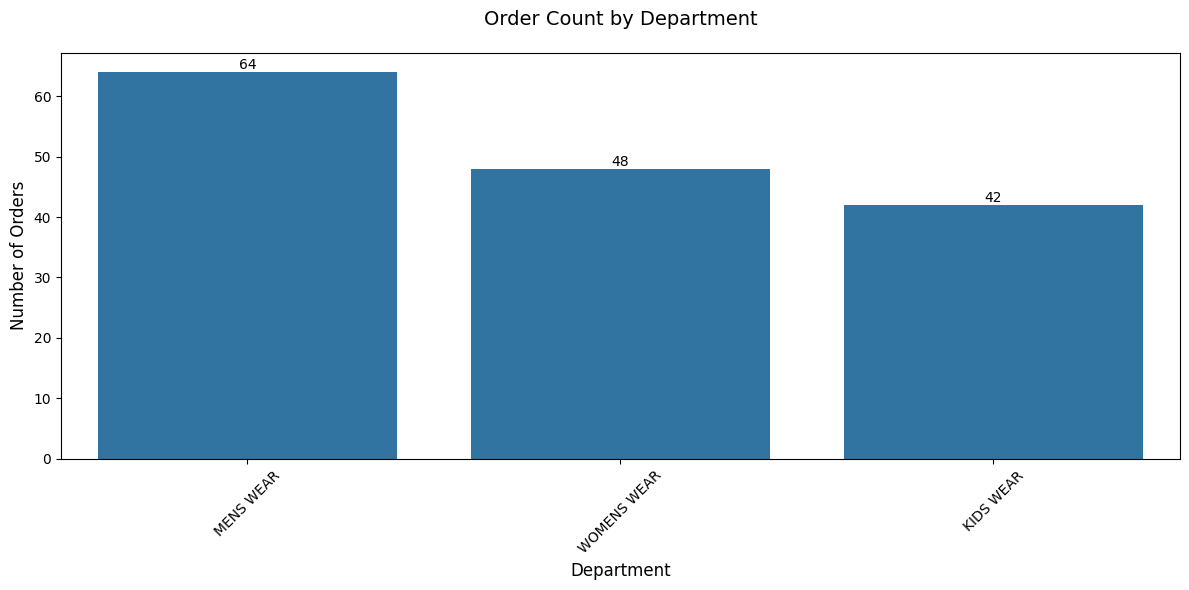

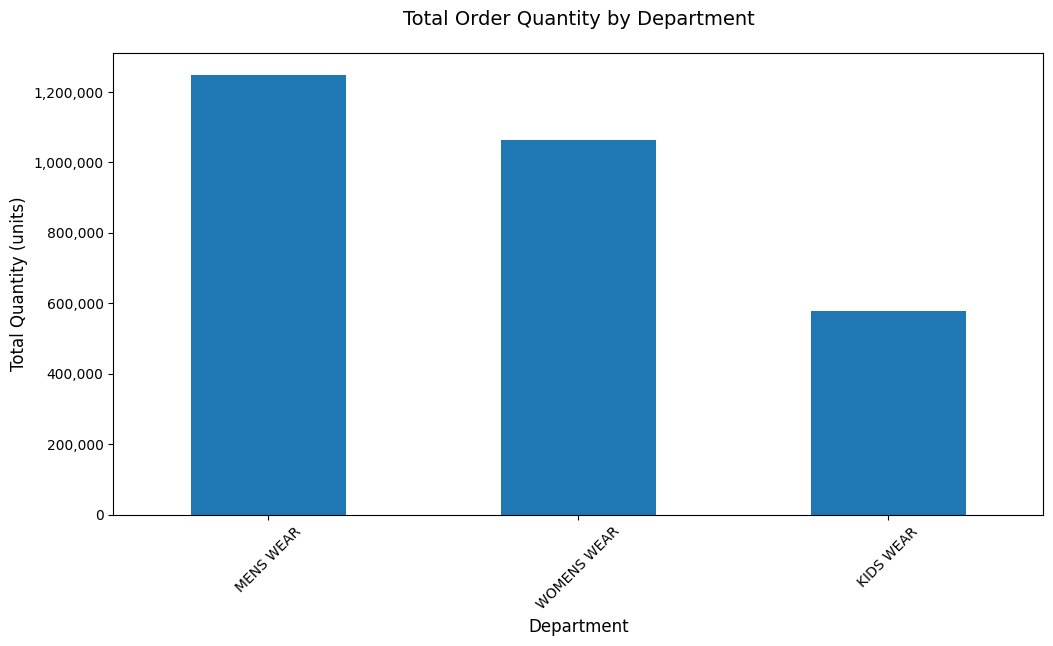

In [11]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='DEPT', order=df['DEPT'].value_counts().index)
plt.title('Order Count by Department', fontsize=14, pad=20)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)

# Add exact counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

# Total quantity by department - improved version
plt.figure(figsize=(12, 6))
dept_qty = df.groupby('DEPT')['QNTY'].sum().sort_values(ascending=False)
ax = dept_qty.plot(kind='bar')

plt.title('Total Order Quantity by Department', fontsize=14, pad=20)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Quantity (units)', fontsize=12)
plt.xticks(rotation=45)

# Format y-axis labels to be more readable
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Add exact values

### Style/Fit Analysis

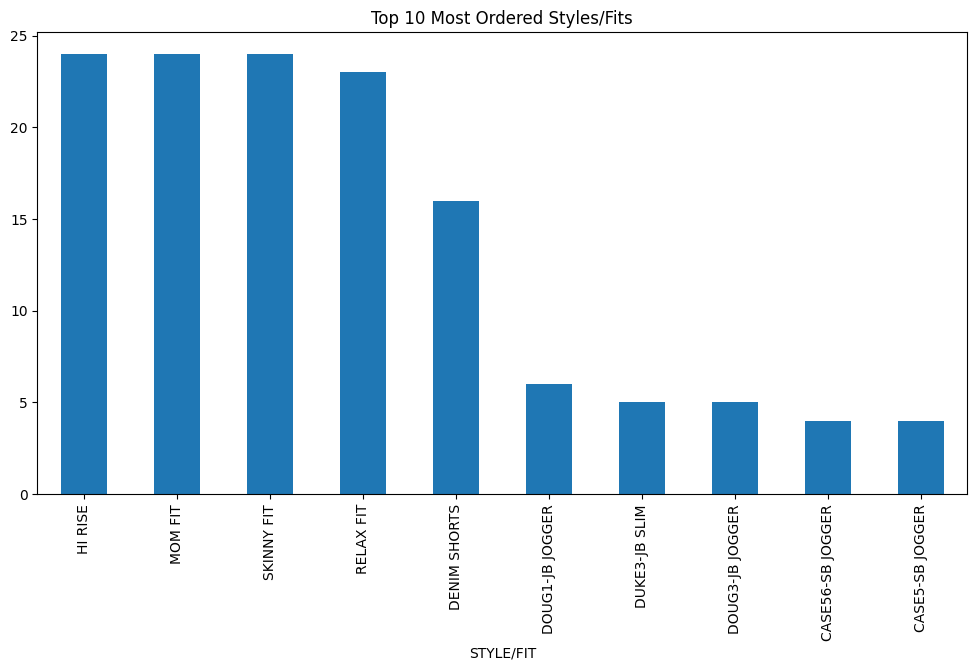

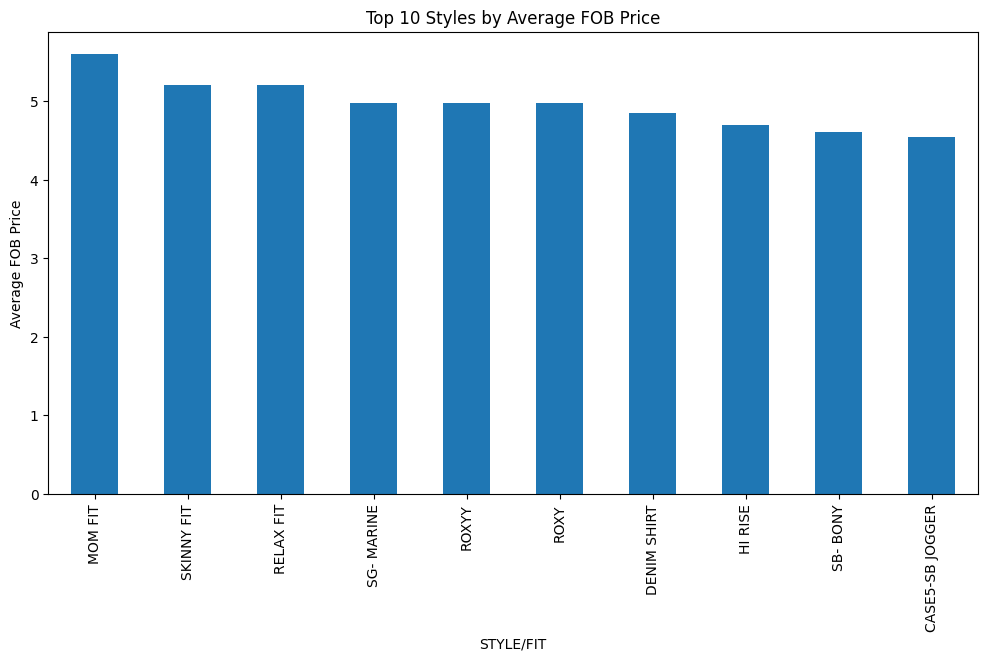

In [12]:
top_styles = df['STYLE/FIT'].value_counts().head(10)
top_styles.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Most Ordered Styles/Fits')
plt.show()

# Average FOB by style
style_fob = df.groupby('STYLE/FIT')['FOB'].mean().sort_values(ascending=False).head(10)
style_fob.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Styles by Average FOB Price')
plt.ylabel('Average FOB Price')
plt.show()


### Time Series Analysis

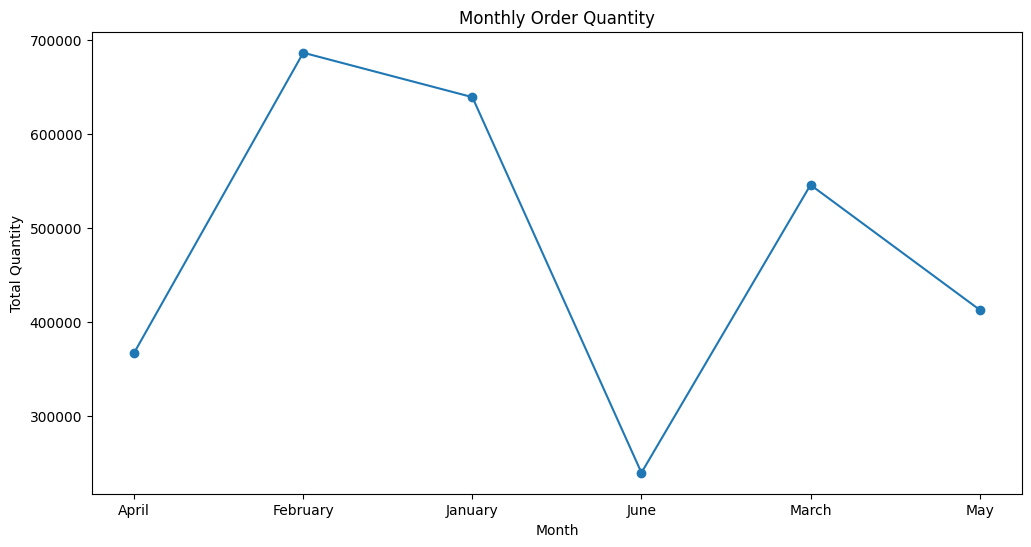

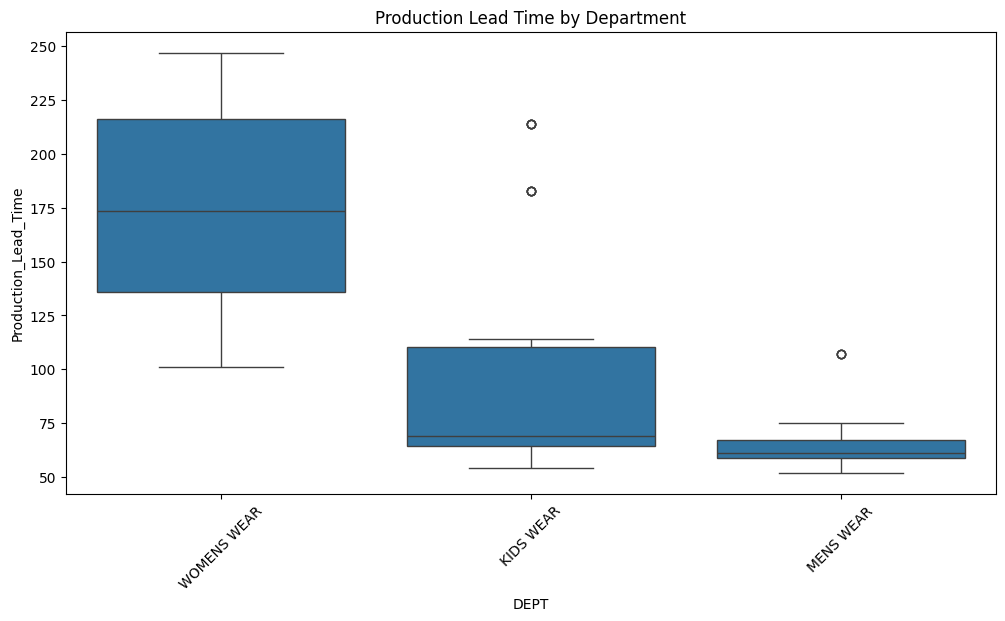

In [13]:
# Monthly order quantity
monthly_qty = df.groupby('Month')['QNTY'].sum()
monthly_qty.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Monthly Order Quantity')
plt.ylabel('Total Quantity')
plt.show()

# Lead time analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='DEPT', y='Production_Lead_Time')
plt.title('Production Lead Time by Department')
plt.xticks(rotation=45)
plt.show()

### Shortage percentage by department


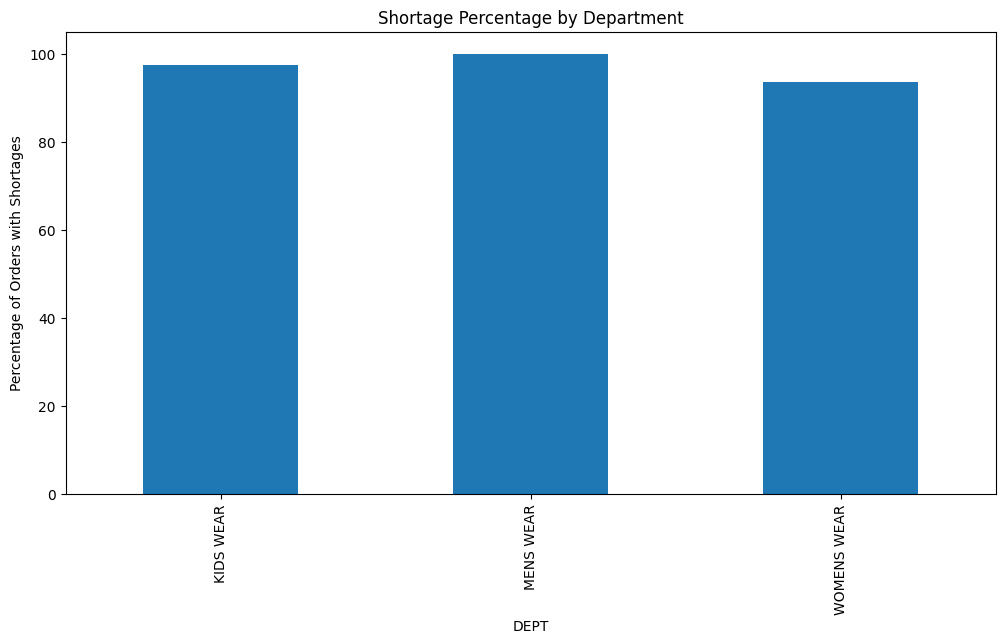

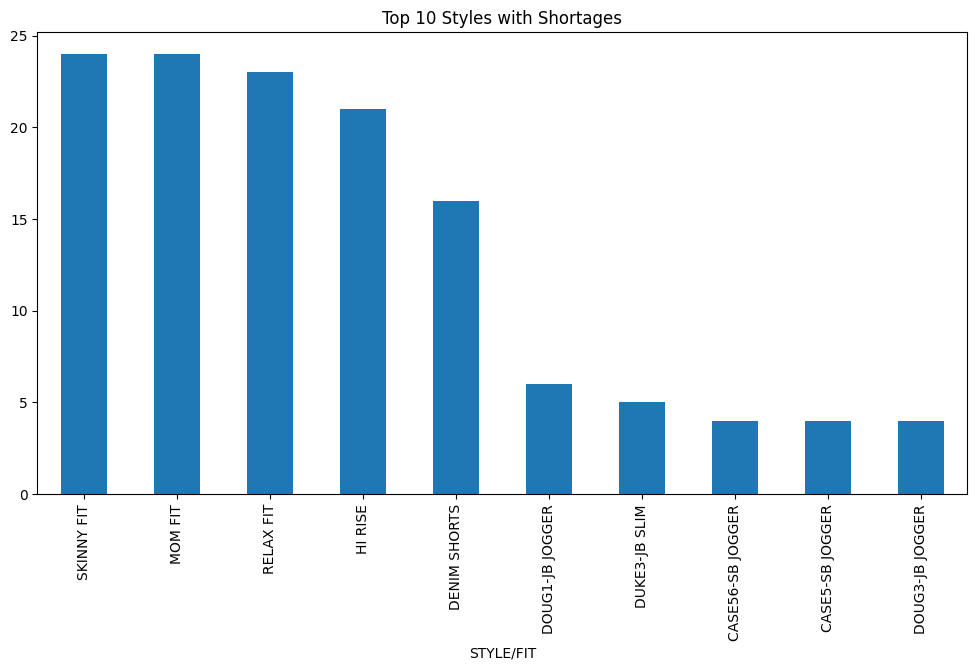

In [14]:
shortage_pct = df.groupby('DEPT')['Shortage_Flag'].mean() * 100
shortage_pct.plot(kind='bar', figsize=(12, 6))
plt.title('Shortage Percentage by Department')
plt.ylabel('Percentage of Orders with Shortages')
plt.show()

# Most problematic styles
problem_styles = df[df['Shortage_Flag'] == 1]['STYLE/FIT'].value_counts().head(10)
problem_styles.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Styles with Shortages')
plt.show()

### Production Unit Analysis

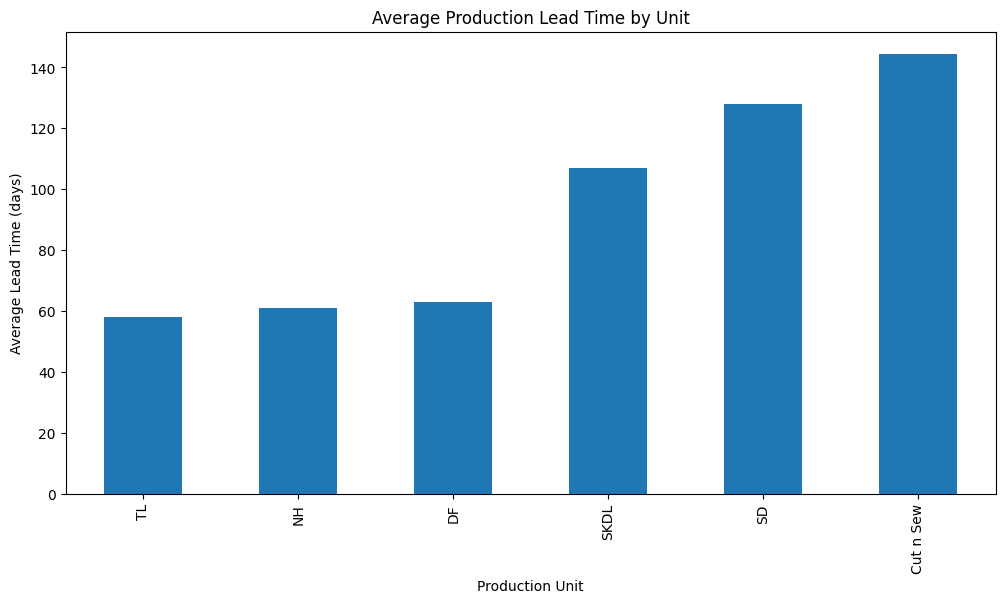

In [15]:
# Production unit efficiency
unit_efficiency = df.groupby('Production Unit')['Production_Lead_Time'].mean().sort_values()
unit_efficiency.plot(kind='bar', figsize=(12, 6))
plt.title('Average Production Lead Time by Unit')
plt.ylabel('Average Lead Time (days)')
plt.show()

### Correlation Analysis

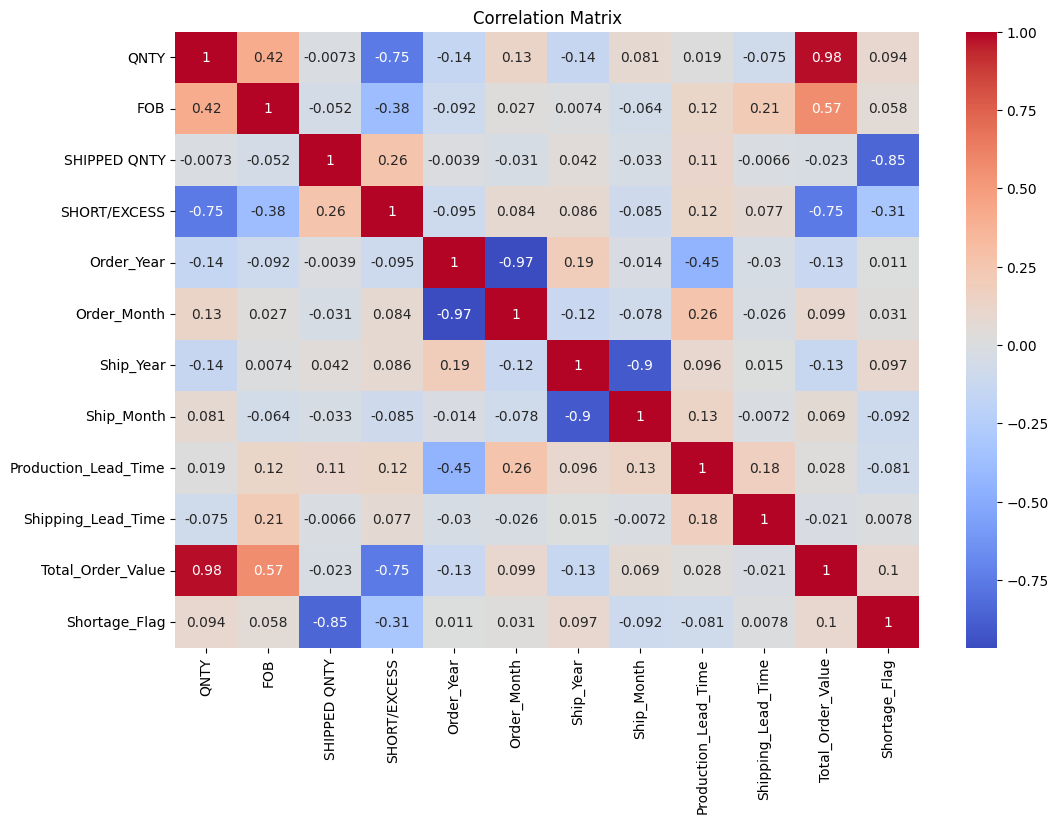

In [16]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [17]:
df

,Month,DEPT,ORDER DATE,STYLE/FIT,WASH/COLOR,QNTY,FOB,SHIP DATE,PCD,SHIPPED QNTY,...,Order_Year,Order_Month,Ship_Year,Ship_Month,Production_Lead_Time,Shipping_Lead_Time,Total_Order_Value,Shortage_Flag,Color_Complexity,Season
0,January,WOMENS WEAR,2024-09-19,HI RISE,BLACK,26171.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,123003.7,1,Simple,Winter
1,January,WOMENS WEAR,2024-09-19,HI RISE,LT INDIGO,24333.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,114365.1,1,Complex,Winter
2,January,WOMENS WEAR,2024-09-19,HI RISE,DK INDIGO,31704.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,149008.8,1,Complex,Winter
3,January,WOMENS WEAR,2024-09-19,HI RISE,WHITE,0.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,0.0,0,Simple,Winter
4,January,WOMENS WEAR,2024-09-19,MOM FIT,BEIGE,26000.0,5.60,2024-12-31,2024-12-06,0,...,2024,9,2024,12,103,8,145600.0,1,Simple,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,May,MENS WEAR,2025-03-06,SKINNY FIT,004-LT GREY,19393.0,5.20,2025-04-27,2025-04-02,0,...,2025,3,2025,4,52,8,100843.6,1,Complex,Summer
150,May,MENS WEAR,2025-02-11,DENIM SHORTS,LT INDIGO,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Complex,Summer
151,May,MENS WEAR,2025-02-11,DENIM SHORTS,BLACK,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Simple,Summer
152,May,MENS WEAR,2025-02-11,DENIM SHORTS,INDIGO,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Complex,Summer


In [18]:

# Define the output file path
output_file = "Processed_Garment_Production2.xlsx"

# Save the DataFrame to an Excel file
df.to_excel(output_file, index=False)

print(f"Data successfully saved to {output_file}")


Data successfully saved to Processed_Garment_Production.xlsx


Revenue calculation successful!
     Month         DEPT ORDER DATE STYLE/FIT WASH/COLOR     QNTY  FOB  \
0  January  WOMENS WEAR 2024-09-19   HI RISE      BLACK  26171.0  4.7   
1  January  WOMENS WEAR 2024-09-19   HI RISE  LT INDIGO  24333.0  4.7   
2  January  WOMENS WEAR 2024-09-19   HI RISE  DK INDIGO  31704.0  4.7   
3  January  WOMENS WEAR 2024-09-19   HI RISE      WHITE      0.0  4.7   
4  January  WOMENS WEAR 2024-09-19   MOM FIT      BEIGE  26000.0  5.6   

   SHIP DATE        PCD  SHIPPED QNTY  ...  Order_Month Ship_Year Ship_Month  \
0 2024-12-29 2024-12-04             0  ...            9      2024         12   
1 2024-12-29 2024-12-04             0  ...            9      2024         12   
2 2024-12-29 2024-12-04             0  ...            9      2024         12   
3 2024-12-29 2024-12-04             0  ...            9      2024         12   
4 2024-12-31 2024-12-06             0  ...            9      2024         12   

   Production_Lead_Time  Shipping_Lead_Time  Tot